# MBTI PERSONALITY CLASSIFIER

Authors: *Xavier Barinaga & Sam Allen*

---

### <u> Our Goal</u>


Classify a user by their personality type, using their latest 50 posts.


### <u> Our Data</u> 

#### The Personality Types

The 4 binary personality types we are trying to predict based of the posts are:

 * `Introversion (I)` *vs.* `Extroversion (E)`
 * `Intuition (N)` *vs.* `Sensing (S)`
 * `Thinking (T)` *vs.* `Feeling (F)`
 * `Judging (J)` *vs.* `Perceiving (P)`


#### The Features:

We extracted the following features from the posts in preprocessing:

`Word Count` - Total Words in the posts

`Polarity` - Measures emotional tone. | **-1.0 (negative) to +1.0 (positive)**  

`Subjectivity` - Measures how personal, opinionated, or factual the text is. | **0.0 (objective) to 1.0 (subjective)**  

`TTR` - Measures word uniqueness | $\frac{\text{Unique Words}}{\text{Total Words}} $

`Adjective Ratio` - Measures Adjective Ratio |  $\frac{\text{Total Adjectives}}{\text{Total Words}} $

`Verb Ratio` - Measures Verb Ratio |  $\frac{\text{Total Adverbs}}{\text{Total Words}} $

`Personal Pronoun Ratio` - Measures Personal Pronoun Ratio |  $\frac{\text{Total Personal Pronouns}}{\text{Total Words}} $

`Third-Person Pronoun Ratio` - Measures Third-Person Pronoun Ratio |  $\frac{\text{Total Third-Person Pronouns}}{\text{Total Words}} $

***~For each instance (user) we are averaging the attribute values across all their posts.***

### <u>Cleaning </u> 

Our data started out with large imbalances. So we decided for each of the 4 target attributes, we will even the distribution before training the model.

Our extracted features came as very specific floating point numbers. We have only implemented categorical implementations of our classification so we had to discretize our extracted features.

Our posts were also seperated by "|||" so we had to break apart the posts by splitting on this. 

There is a certain point at which we have to accept that natural language is messy, especially posts. This means we can't go through each post individually to personally see if we think the post is useful or not. For example, some people might just post a link to a youtube video. Something like that is just part of processing posts.

### <u>Findings </u> 
As a brief overview, we found our Random Forest algorithm performed the best across the four binary classifiers. Specifically, the Thinking vs Feeling classifier had the best results. As we will explore, this is because our features were best suited for this specific classifier.

In [ ]:
# some useful mysklearn package import statements and reloads
import importlib

import myutils
importlib.reload(myutils)
import myutils as myutils

# uncomment once you paste your mypytable.py into mysklearn package
import mypytable
importlib.reload(mypytable)
from mypytable import MyPyTable 

# uncomment once you paste your myclassifiers.py into mysklearn package
import myclassifiers
importlib.reload(myclassifiers)

import myevaluation
importlib.reload(myevaluation)
import myevaluation as myevaluation

import matplotlib.pyplot as plt
from tabulate import tabulate

In [334]:
mbti = MyPyTable()
mbti.load_from_file("categorical.csv")

ie = []
ns = []
tf = []
jp = []

# Discretize each numeric column and separate into 4 different mbti tables for feature manipulation
mbti = myutils.discretize(mbti, 10) # general purpose mbti table
mbti_ie = myutils.discretize(mbti, 10)
mbti_ns = myutils.discretize(mbti, 10)
mbti_tf = myutils.discretize(mbti, 10)
mbti_jp = myutils.discretize(mbti, 10)

# Separate each unique class label
for row in mbti.data:
    ie.append(row[0][0]) # append I for introversion or E for extroversion
    ns.append(row[0][1]) # append N for Intution or S for sensing
    tf.append(row[0][2]) # append T for Thinking or F for feeling
    jp.append(row[0][3]) # append J for Judging or P for perceiving

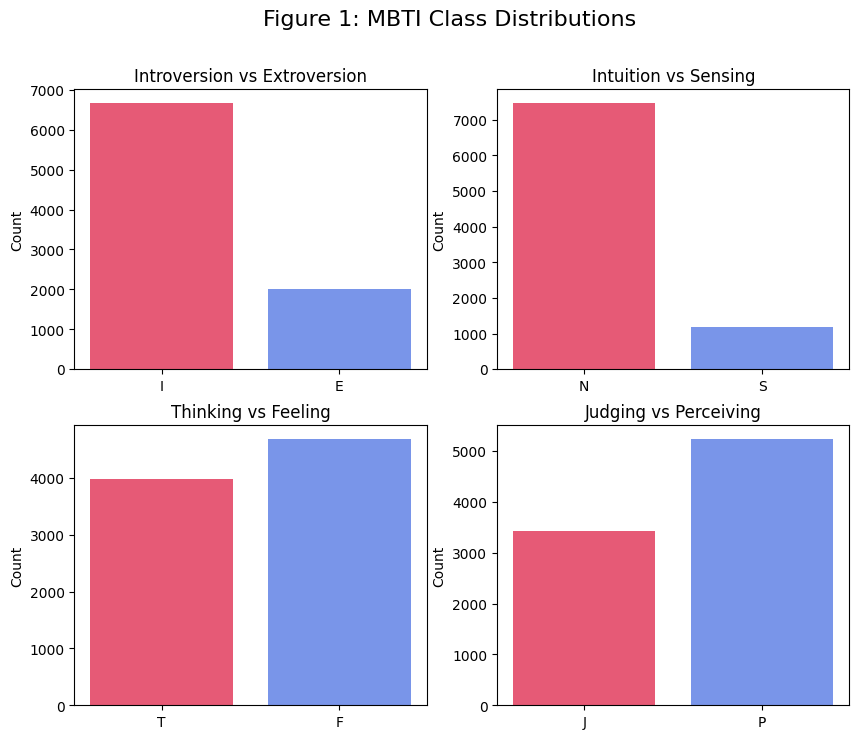

In [335]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Figure 1: MBTI Class Distributions", fontsize=16)

myutils.create_bar(axs[0, 0], ie, "Introversion vs Extroversion", ["I", "E"])
myutils.create_bar(axs[0, 1], ns, "Intuition vs Sensing", ["N", "S"])
myutils.create_bar(axs[1, 0], tf, "Thinking vs Feeling", ["T", "F"])
myutils.create_bar(axs[1, 1], jp, "Judging vs Perceiving", ["J", "P"])

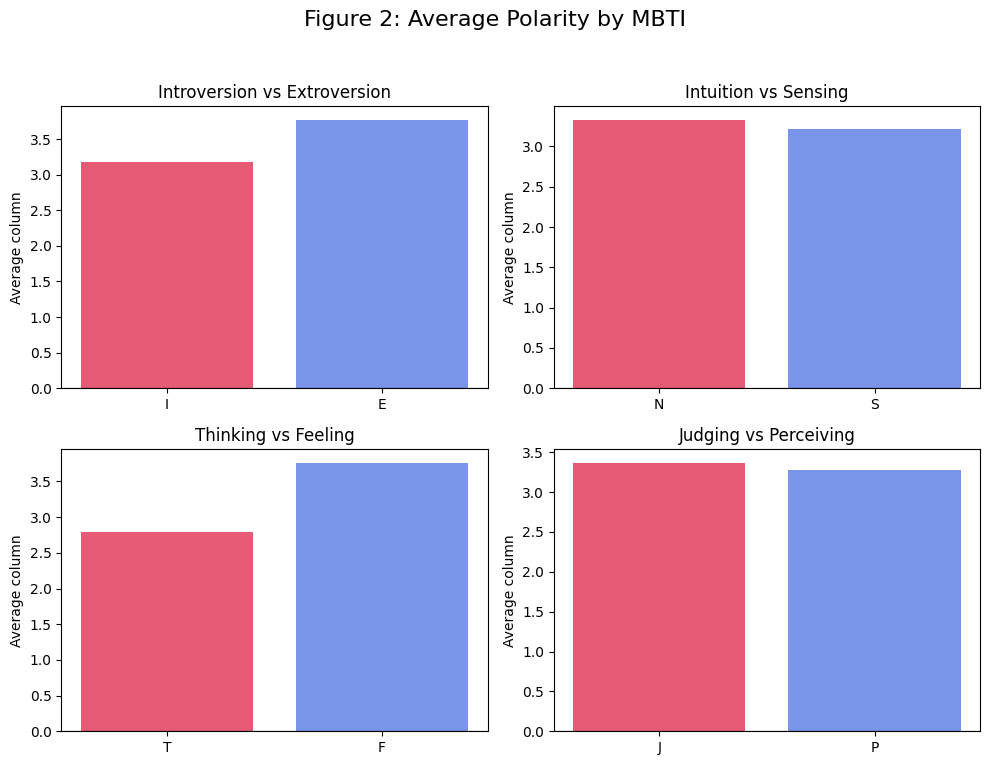

In [336]:
# Graphs for avg column
column = mbti.get_column("Polarity")

# Setup figure
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Figure 2: Average Polarity by MBTI", fontsize=16)

myutils.plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
myutils.plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
myutils.plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
myutils.plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

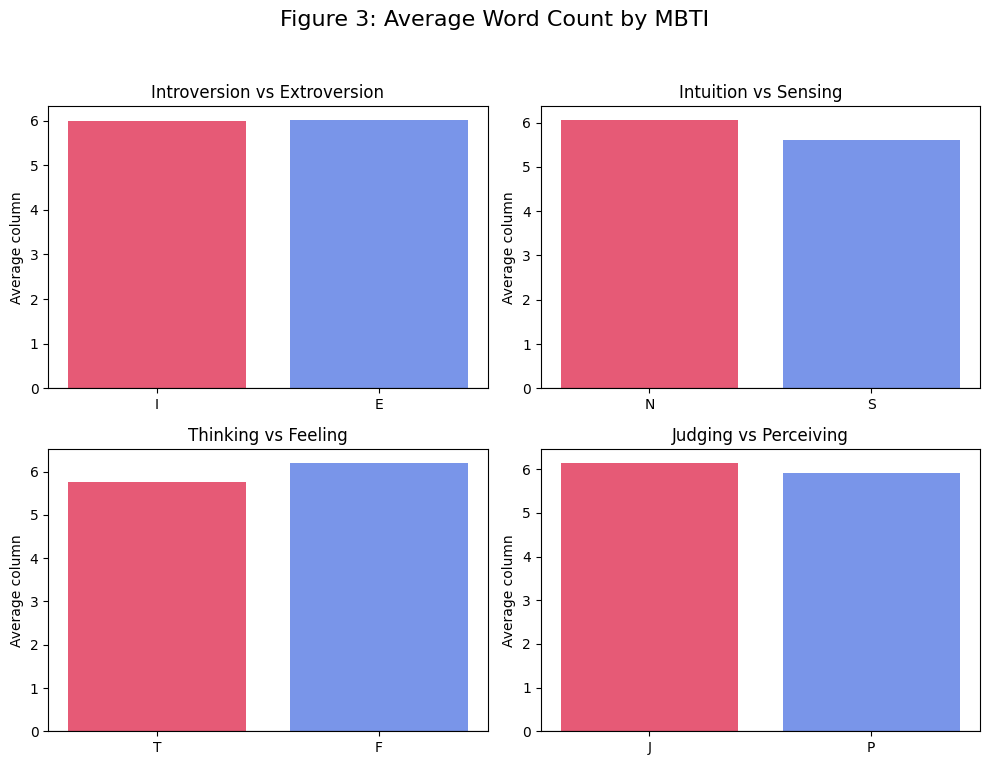

In [337]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Figure 3: Average Word Count by MBTI", fontsize=16)

# Graphs for avg subjectivity
subjectivity = mbti.get_column("Word Count")



# Plot each dimension
myutils.plot_avg_column(axs[0, 0], ie, subjectivity, 'Introversion vs Extroversion', ['I', 'E'])
myutils.plot_avg_column(axs[0, 1], ns, subjectivity, 'Intuition vs Sensing', ['N', 'S'])
myutils.plot_avg_column(axs[1, 0], tf, subjectivity, 'Thinking vs Feeling', ['T', 'F'])
myutils.plot_avg_column(axs[1, 1], jp, subjectivity, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

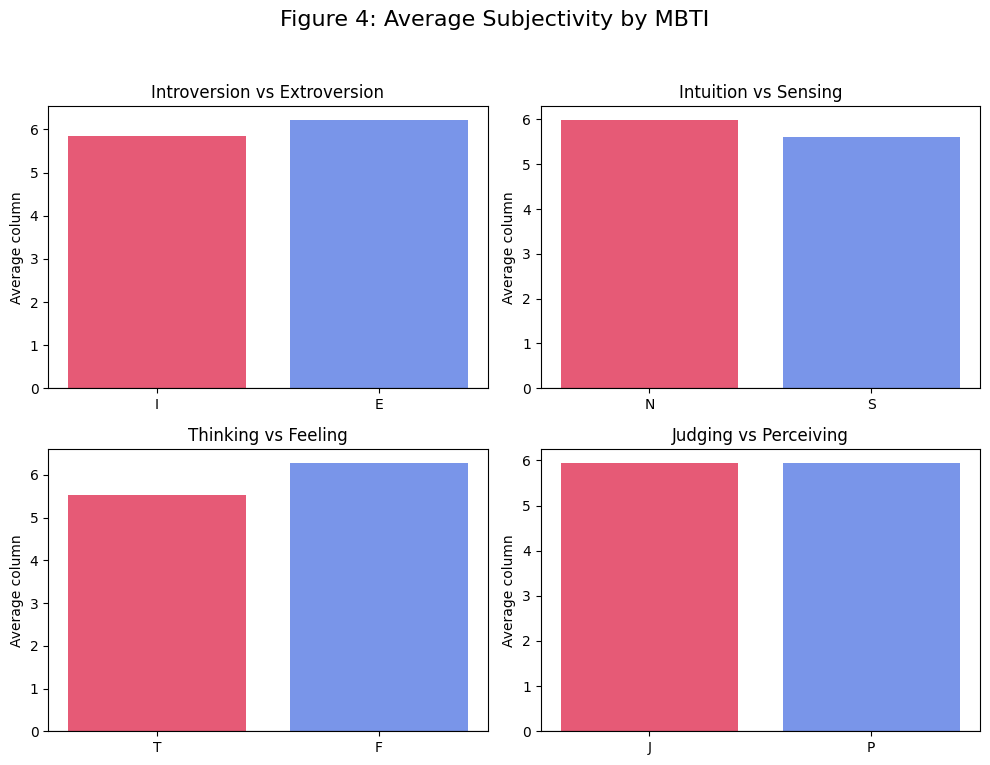

In [338]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Figure 4: Average Subjectivity by MBTI", fontsize=16)

# Graphs for avg subjectivity
subjectivity = mbti.get_column("Subjectivity")



# Plot each dimension
myutils.plot_avg_column(axs[0, 0], ie, subjectivity, 'Introversion vs Extroversion', ['I', 'E'])
myutils.plot_avg_column(axs[0, 1], ns, subjectivity, 'Intuition vs Sensing', ['N', 'S'])
myutils.plot_avg_column(axs[1, 0], tf, subjectivity, 'Thinking vs Feeling', ['T', 'F'])
myutils.plot_avg_column(axs[1, 1], jp, subjectivity, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

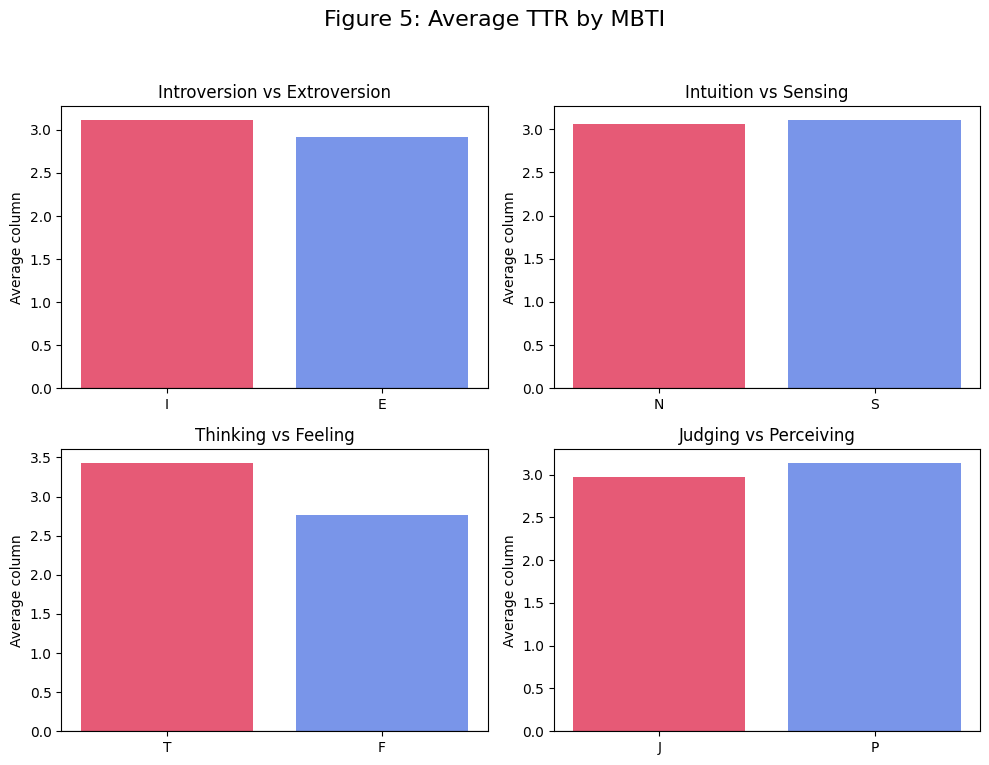

In [339]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Figure 5: Average TTR by MBTI", fontsize=16)

# Graphs for avg subjectivity
column = mbti.get_column("TTR")



# Plot each dimension
myutils.plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
myutils.plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
myutils.plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
myutils.plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

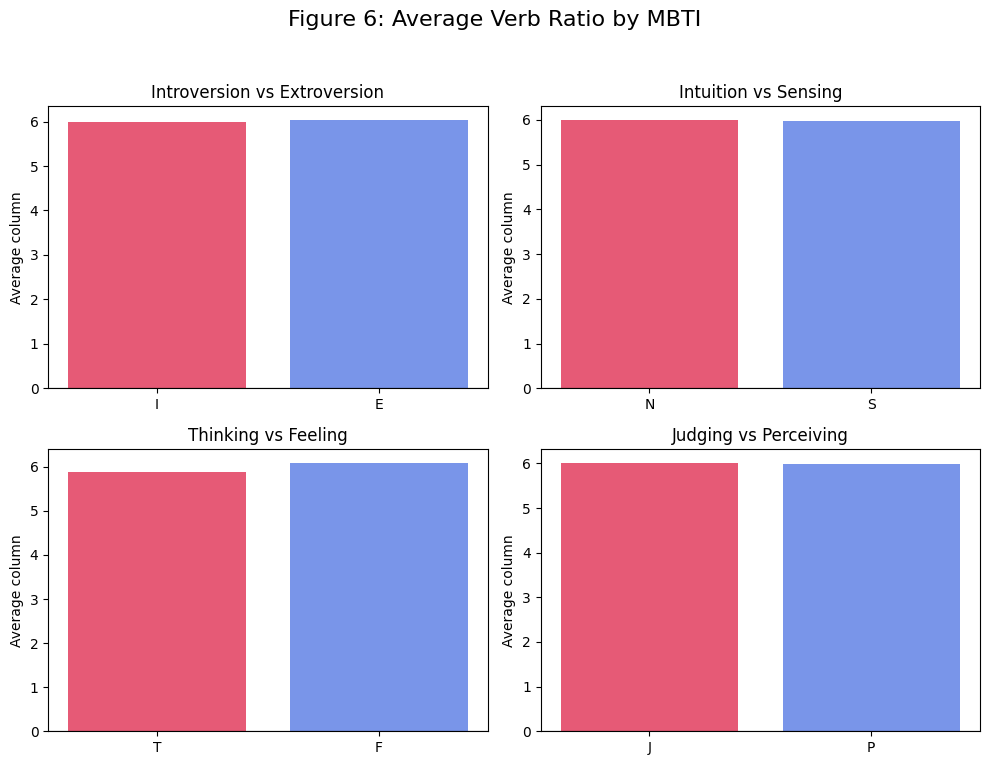

In [340]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Figure 6: Average Verb Ratio by MBTI", fontsize=16)

# Graphs for avg subjectivity
column = mbti.get_column("Verb Ratio")

# Plot each dimension
myutils.plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
myutils.plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
myutils.plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
myutils.plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

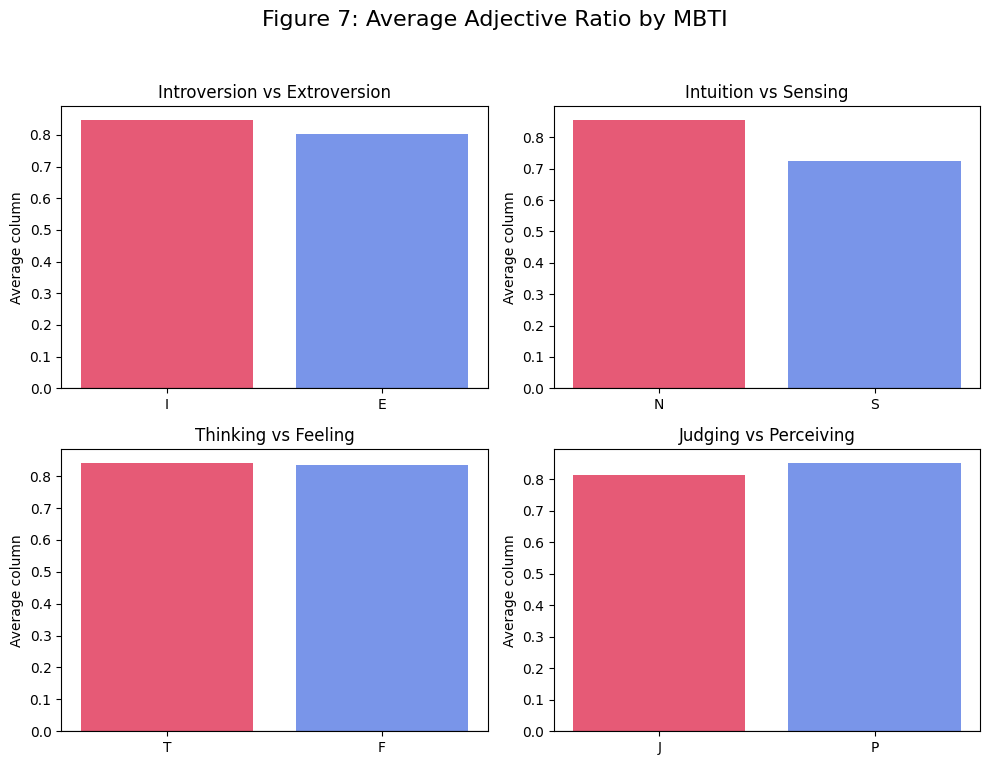

In [341]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Figure 7: Average Adjective Ratio by MBTI", fontsize=16)

# Graphs for avg subjectivity
column = mbti.get_column("Adjective Ratio")

# Plot each dimension
myutils.plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
myutils.plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
myutils.plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
myutils.plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

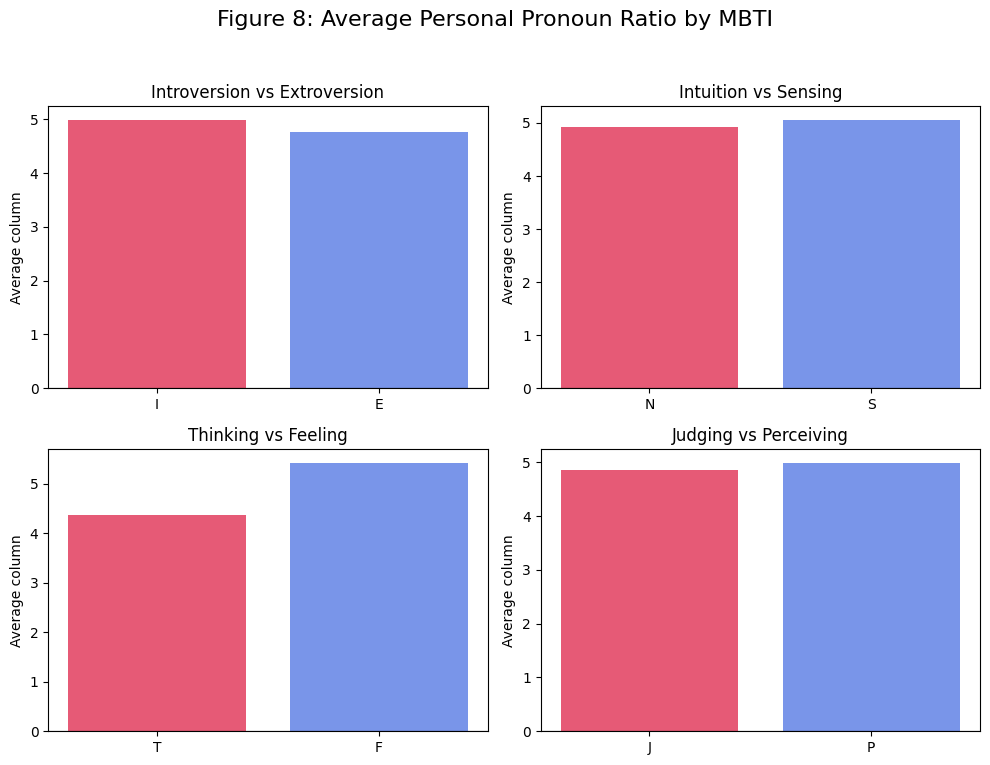

In [342]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Figure 8: Average Personal Pronoun Ratio by MBTI", fontsize=16)

# Graphs for avg subjectivity
column = mbti.get_column("Personal Pronoun Ratio")

# Plot each dimension
myutils.plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
myutils.plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
myutils.plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
myutils.plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

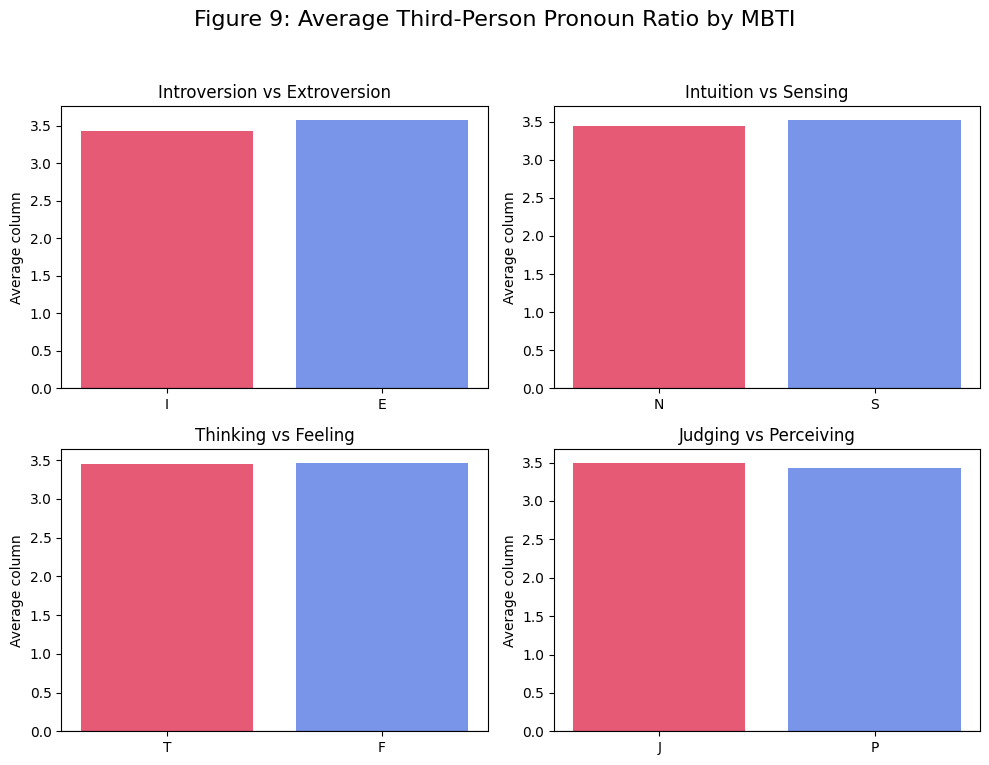

In [343]:
fig, axs = plt.subplots(2, 2, figsize = (10,8))
fig.suptitle("Figure 9: Average Third-Person Pronoun Ratio by MBTI", fontsize=16)

# Graphs for avg subjectivity
column = mbti.get_column("Third-Person Pronoun Ratio")

# Plot each dimension
myutils.plot_avg_column(axs[0, 0], ie, column, 'Introversion vs Extroversion', ['I', 'E'])
myutils.plot_avg_column(axs[0, 1], ns, column, 'Intuition vs Sensing', ['N', 'S'])
myutils.plot_avg_column(axs[1, 0], tf, column, 'Thinking vs Feeling', ['T', 'F'])
myutils.plot_avg_column(axs[1, 1], jp, column, 'Judging vs Perceiving', ['J', 'P'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Data Visualization Results
As we can see from the above graphs, many of our features have relatively little to no impact in differentiating our classes. As you will see below, this heaviliy impacts the performance of our classifiers.

We will optimize the features each classifier uses based on the results above. For example, from the graphs we can see that for Thinking vs Feeling, personal pronoun ratio seems to be somewhat differentiating between the two classes. In this case, we specifically will include this in the Thinking vs Feeling classifier but not the others since it is only differentiating for that classifier as we can see in the graph.

## Feature Selection
Using the data visualization results, we will select the most informative features to keep for each binary classifier.

**Introvert/Extrovert Classifier:**
 * This classifier only had one feature with any slight difference between the classes.
   * The difference in polarity for the means of introverts vs extroverts amounted to about 0.5 (about a 15% difference).
 * Since this is the only feature with any meaningful difference, and we did not want to have a single-feature classifier, we decided to just have the Introvert/Extrovert classifier use all attributes.

**Intuition/Sensing Classifier:**
 * Similarily, this classifier only had one feature with any slight difference between the classes.
   * The difference in adjective ratio for the means of intuition vs sensing amounted to about 0.1 (about a 15% difference).
 * Since this is the only feature with any meaningful difference, and we did not want to have a single-feature classifier, we decided to just have the Intuition/Sensing classifier use all attributes as well.

**Thinking/Feeling Classifier:**
 * Subjectivity, TTR, personal pronoun ratio, and polarity were our most differentiating statistics.
   * We chose to use these four features as the only features for our Thinking/Feeling classifier as it significantly boosted the results.

**Judging/Perceiving Classifier:**
 * Across the EDA, we can see that there is no feature of ours that creates meaningful separation between the two classes.
 * Since there is no meaningful difference between featuures,  we decided to just have the Judging/Perceiving classifier use all attributes.

In [344]:
# ------------------ Introvert/Extrovert Classifier ------------------------- #
mbti_ie.drop_column("type")
# mbti_ie.drop_column("Word Count")
# mbti_ie.drop_column("Polarity")
# mbti_ie.drop_column("TTR")
# mbti_ie.drop_column("Subjectivity")
# mbti_ie.drop_column("Verb Ratio")
# mbti_ie.drop_column("Adjective Ratio")
# mbti_ie.drop_column("Personal Pronoun Ratio")
# mbti_ie.drop_column("Third-Person Pronoun Ratio")
# --------------------------------------------------------------------------- #

# -------------------- Intuition/Sensing Classifier ------------------------- #
mbti_ns.drop_column("type")
# mbti_ns.drop_column("Word Count")
# mbti_ns.drop_column("Polarity")
# mbti_ns.drop_column("TTR")
# mbti_ns.drop_column("Subjectivity")
# mbti_ns.drop_column("Verb Ratio")
# mbti_ns.drop_column("Adjective Ratio")
# mbti_ns.drop_column("Personal Pronoun Ratio")
# mbti_ns.drop_column("Third-Person Pronoun Ratio")
# --------------------------------------------------------------------------- #

# --------------------- Thinking/Feeling Classifier ------------------------- #
mbti_tf.drop_column("type")
mbti_tf.drop_column("Word Count")
# mbti_tf.drop_column("Polarity")
# mbti_tf.drop_column("TTR")
# mbti_tf.drop_column("Subjectivity")
mbti_tf.drop_column("Verb Ratio")
mbti_tf.drop_column("Adjective Ratio")
# mbti_tf.drop_column("Personal Pronoun Ratio")
mbti_tf.drop_column("Third-Person Pronoun Ratio")
# --------------------------------------------------------------------------- #

# ------------------- Judging/Perceiving Classifier ------------------------- #
mbti_jp.drop_column("type")
# mbti_jp.drop_column("Word Count")
# mbti_jp.drop_column("Polarity")
# mbti_jp.drop_column("TTR")
# mbti_jp.drop_column("Subjectivity")
# mbti_jp.drop_column("Verb Ratio")
# mbti_jp.drop_column("Adjective Ratio")
# mbti_jp.drop_column("Personal Pronoun Ratio")
# mbti_jp.drop_column("Third-Person Pronoun Ratio")
# --------------------------------------------------------------------------- #

In [345]:
# Even out class distributions
new_data_ie, new_column_ie = mbti_ie.even_class_distribution(ie)
new_data_ns, new_column_ns = mbti_ns.even_class_distribution(ns)
new_data_tf, new_column_tf = mbti_tf.even_class_distribution(tf)
new_data_jp, new_column_jp = mbti_jp.even_class_distribution(jp)

In [346]:
print(
"""
================================================================
        Total Instances (After evening class imbalance)
================================================================
""")
print("Introvert vs Extrovert Classifier:", len(new_column_ie))
print("ntuition vs Sensing Classifier:", len(new_column_ns))
print("Thinking vs Feeling Classifier:", len(new_column_tf))
print("Judging vs Perceiving Classifier:", len(new_column_jp))


        Total Instances (After evening class imbalance)

Introvert vs Extrovert Classifier: 3998
ntuition vs Sensing Classifier: 2394
Thinking vs Feeling Classifier: 7962
Judging vs Perceiving Classifier: 6868


In [347]:
X_ie = new_data_ie.data
y_ie = new_column_ie
X_ns = new_data_ns.data
y_ns = new_column_ns
X_tf = new_data_tf.data
y_tf = new_column_tf
X_jp = new_data_jp.data
y_jp = new_column_jp

## kNN Classifier
Below we will explore the accuracy of our kNN algorithm for each of our personality types. In general, our kNN algorithm performed the best using 51 neighbors.

In [348]:
knn_ie = myclassifiers.MyKNeighborsClassifier(n_neighbors=51)
X_train_ie, X_test_ie, y_train_ie, y_test_ie = myevaluation.stratified_split(X_ie, y_ie, test_size=0.33, random_state=42)

knn_ns = myclassifiers.MyKNeighborsClassifier(n_neighbors=51)
X_train_ns, X_test_ns, y_train_ns, y_test_ns = myevaluation.stratified_split(X_ns, y_ns, test_size=0.33, random_state=42)

knn_tf = myclassifiers.MyKNeighborsClassifier(n_neighbors=51)
X_train_tf, X_test_tf, y_train_tf, y_test_tf = myevaluation.stratified_split(X_tf, y_tf, test_size=0.33, random_state=42)

knn_jp = myclassifiers.MyKNeighborsClassifier(n_neighbors=51)
X_train_jp, X_test_jp, y_train_jp, y_test_jp = myevaluation.stratified_split(X_jp, y_jp, test_size=0.33, random_state=42)

In [349]:
knn_ie.fit(X_train_ie, y_train_ie)
y_pred_ie = knn_ie.predict(X_test_ie)

knn_ns.fit(X_train_ns, y_train_ns)
y_pred_ns = knn_ns.predict(X_test_ns)

knn_tf.fit(X_train_tf, y_train_tf)
y_pred_tf = knn_tf.predict(X_test_tf)

knn_jp.fit(X_train_jp, y_train_jp)
y_pred_jp = knn_jp.predict(X_test_jp)

In [350]:
print(
"""
===========================================
          kNN Predictive Accuracy
===========================================
"""
f"kNN Classifier for Introversion: Accuracy = {round(myevaluation.accuracy_score(y_test_ie, y_pred_ie), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_ie, y_pred_ie, ['I', 'E']), 2)}\n"
f"kNN Classifier for Intuition: Accuracy = {round(myevaluation.accuracy_score(y_test_ns, y_pred_ns), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_ns, y_pred_ns, ['N', 'S']), 2)}\n"
f"kNN Classifier for Thinking: Accuracy = {round(myevaluation.accuracy_score(y_test_tf, y_pred_tf), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_tf, y_pred_tf, ['T', 'F']), 2)}\n"
f"kNN Classifier for Judging: Accuracy = {round(myevaluation.accuracy_score(y_test_jp, y_pred_jp), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_jp, y_pred_jp, ['J', 'P']), 2)} \n"
)


          kNN Predictive Accuracy
kNN Classifier for Introversion: Accuracy = 0.54, F1 Score: 0.56
kNN Classifier for Intuition: Accuracy = 0.52, F1 Score: 0.52
kNN Classifier for Thinking: Accuracy = 0.61, F1 Score: 0.63
kNN Classifier for Judging: Accuracy = 0.52, F1 Score: 0.53 



In [351]:
header = ["", "Introvert", "Extrovert", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_ie, y_pred_ie, ['I', 'E']), ['Introvert', 'Extrovert']), headers=header))

             Introvert    Extrovert    Total  Recognition (%)
---------  -----------  -----------  -------  -----------------
Introvert          383          276      659  58.12%
Extrovert          325          334      659  50.68%


In [352]:
header = ["", "Intuition", "Sensing", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_ns, y_pred_ns, ['N', 'S']), ['Intuition', 'Sensing']), headers=header))

             Intuition    Sensing    Total  Recognition (%)
---------  -----------  ---------  -------  -----------------
Intuition          211        184      395  53.42%
Sensing            199        196      395  49.62%


In [353]:
header = ["", "Thinking", "Feeling", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_tf, y_pred_tf, ['T', 'F']), ['Thinking', 'Feeling']), headers=header))

            Thinking    Feeling    Total  Recognition (%)
--------  ----------  ---------  -------  -----------------
Thinking         885        428     1313  67.40%
Feeling          608        705     1313  53.69%


In [354]:
header = ["", "Judging", "Perceiving", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_jp, y_pred_jp, ['J', 'P']), ['Judging', 'Perceiving']), headers=header))

              Judging    Perceiving    Total  Recognition (%)
----------  ---------  ------------  -------  -----------------
Judging           611           522     1133  53.93%
Perceiving        567           566     1133  49.96%


### Decision Tree

In [355]:
dt_ie = myclassifiers.MyDecisionTreeClassifier()
X_train_ie, X_test_ie, y_train_ie, y_test_ie = myevaluation.stratified_split(X_ie, y_ie, test_size=0.33, random_state=42)

dt_ns = myclassifiers.MyDecisionTreeClassifier()
X_train_ns, X_test_ns, y_train_ns, y_test_ns = myevaluation.stratified_split(X_ns, y_ns, test_size=0.33, random_state=42)

dt_tf = myclassifiers.MyDecisionTreeClassifier()
X_train_tf, X_test_tf, y_train_tf, y_test_tf = myevaluation.stratified_split(X_tf, y_tf, test_size=0.33, random_state=42)

dt_jp = myclassifiers.MyDecisionTreeClassifier()
X_train_jp, X_test_jp, y_train_jp, y_test_jp = myevaluation.stratified_split(X_jp, y_jp, test_size=0.33, random_state=42)

In [356]:
dt_ie.fit(X_train_ie, y_train_ie)
y_pred_ie = dt_ie.predict(X_test_ie)

dt_ns.fit(X_train_ns, y_train_ns)
y_pred_ns = dt_ns.predict(X_test_ns)

dt_tf.fit(X_train_tf, y_train_tf)
y_pred_tf = dt_tf.predict(X_test_tf)

dt_jp.fit(X_train_jp, y_train_jp)
y_pred_jp = dt_jp.predict(X_test_jp)

In [357]:
print(
"""
===========================================
     Decision Tree Predictive Accuracy     
===========================================
"""
f"Decision Tree Classifier for Introversion: Accuracy = {round(myevaluation.accuracy_score(y_test_ie, y_pred_ie), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_ie, y_pred_ie, ['I', 'E']), 2)}\n"
f"Decision Tree Classifier for Intuition: Accuracy = {round(myevaluation.accuracy_score(y_test_ns, y_pred_ns), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_ns, y_pred_ns, ['N', 'S']), 2)}\n"
f"Decision Tree Classifier for Thinking: Accuracy = {round(myevaluation.accuracy_score(y_test_tf, y_pred_tf), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_tf, y_pred_tf, ['T', 'F']), 2)}\n"
f"Decision Tree Classifier for Judging: Accuracy = {round(myevaluation.accuracy_score(y_test_jp, y_pred_jp), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_jp, y_pred_jp, ['J', 'P']), 2)} \n"
)


     Decision Tree Predictive Accuracy     
Decision Tree Classifier for Introversion: Accuracy = 0.53, F1 Score: 0.51
Decision Tree Classifier for Intuition: Accuracy = 0.54, F1 Score: 0.57
Decision Tree Classifier for Thinking: Accuracy = 0.6, F1 Score: 0.58
Decision Tree Classifier for Judging: Accuracy = 0.5, F1 Score: 0.52 



In [358]:
header = ["", "Introvert", "Extrovert", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_ie, y_pred_ie, ['I', 'E']), ['Introvert', 'Extrovert']), headers=header))

             Introvert    Extrovert    Total  Recognition (%)
---------  -----------  -----------  -------  -----------------
Introvert          326          333      659  49.47%
Extrovert          292          367      659  55.69%


In [359]:
header = ["", "Intuition", "Sensing", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_ns, y_pred_ns, ['N', 'S']), ['Intuition', 'Sensing']), headers=header))

             Intuition    Sensing    Total  Recognition (%)
---------  -----------  ---------  -------  -----------------
Intuition          241        154      395  61.01%
Sensing            210        185      395  46.84%


In [360]:
header = ["", "Thinking", "Feeling", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_tf, y_pred_tf, ['T', 'F']), ['Thinking', 'Feeling']), headers=header))

            Thinking    Feeling    Total  Recognition (%)
--------  ----------  ---------  -------  -----------------
Thinking         733        580     1313  55.83%
Feeling          474        839     1313  63.90%


In [361]:
header = ["", "Judging", "Perceiving", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_jp, y_pred_jp, ['J', 'P']), ['Judging', 'Perceiving']), headers=header))

              Judging    Perceiving    Total  Recognition (%)
----------  ---------  ------------  -------  -----------------
Judging           621           512     1133  54.81%
Perceiving        614           519     1133  45.81%


## Decision Tree Results
Overall our decision tree shows that we effectively do no better than random guessing for 3 of our 4 binary classifiers. Our best classifier is still proving to be Thinking/Feeling where we were able to find the most representative features.

### Random Forest

In [362]:
rf_ie = myclassifiers.MyRandomForestClassifier(n_estimators=50, n_features=0.6, m=25)
X_train_ie, X_test_ie, y_train_ie, y_test_ie = myevaluation.stratified_split(X_ie, y_ie, test_size=0.33, random_state=0)

rf_ns = myclassifiers.MyRandomForestClassifier(n_estimators=50, n_features=0.6, m=25)
X_train_ns, X_test_ns, y_train_ns, y_test_ns = myevaluation.stratified_split(X_ns, y_ns, test_size=0.33, random_state=0)

rf_tf = myclassifiers.MyRandomForestClassifier(n_estimators=50, n_features=0.6, m=25)
X_train_tf, X_test_tf, y_train_tf, y_test_tf = myevaluation.stratified_split(X_tf, y_tf, test_size=0.33, random_state=0)

rf_jp = myclassifiers.MyRandomForestClassifier(n_estimators=50, n_features=0.6, m=25)
X_train_jp, X_test_jp, y_train_jp, y_test_jp = myevaluation.stratified_split(X_jp, y_jp, test_size=0.33, random_state=0)

In [363]:
rf_ie.fit(X_train_ie, y_train_ie)
y_pred_ie = rf_ie.predict(X_test_ie)

rf_ns.fit(X_train_ns, y_train_ns)
y_pred_ns = rf_ns.predict(X_test_ns)

rf_tf.fit(X_train_tf, y_train_tf)
y_pred_tf = rf_tf.predict(X_test_tf)

rf_jp.fit(X_train_jp, y_train_jp)
y_pred_jp = rf_jp.predict(X_test_jp)

In [364]:
print(
"""
===========================================
     Random Forest Predictive Accuracy
===========================================
"""
f"Random Forest Classifier for Introversion: Accuracy = {round(myevaluation.accuracy_score(y_test_ie, y_pred_ie), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_ie, y_pred_ie, ['I', 'E']), 2)}\n"
f"Random Forest Classifier for Intuition: Accuracy = {round(myevaluation.accuracy_score(y_test_ns, y_pred_ns), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_ns, y_pred_ns, ['N', 'S']), 2)}\n"
f"Random Forest Classifier for Thinking: Accuracy = {round(myevaluation.accuracy_score(y_test_tf, y_pred_tf), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_tf, y_pred_tf, ['T', 'F']), 2)}\n"
f"Random Forest Classifier for Judging: Accuracy = {round(myevaluation.accuracy_score(y_test_jp, y_pred_jp), 2)}, F1 Score: {round(myevaluation.binary_f1_score(y_test_jp, y_pred_jp, ['J', 'P']), 2)} \n"
)


     Random Forest Predictive Accuracy
Random Forest Classifier for Introversion: Accuracy = 0.54, F1 Score: 0.52
Random Forest Classifier for Intuition: Accuracy = 0.53, F1 Score: 0.57
Random Forest Classifier for Thinking: Accuracy = 0.62, F1 Score: 0.64
Random Forest Classifier for Judging: Accuracy = 0.5, F1 Score: 0.55 



In [365]:
header = ["", "Introvert", "Extrovert", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_ie, y_pred_ie, ['I', 'E']), ['Introvert', 'Extrovert']), headers=header))

             Introvert    Extrovert    Total  Recognition (%)
---------  -----------  -----------  -------  -----------------
Introvert          323          336      659  49.01%
Extrovert          269          390      659  59.18%


In [366]:
header = ["", "Intuition", "Sensing", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_ns, y_pred_ns, ['N', 'S']), ['Intuition', 'Sensing']), headers=header))

             Intuition    Sensing    Total  Recognition (%)
---------  -----------  ---------  -------  -----------------
Intuition          247        148      395  62.53%
Sensing            220        175      395  44.30%


In [367]:
header = ["", "Thinking", "Feeling", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_tf, y_pred_tf, ['T', 'F']), ['Thinking', 'Feeling']), headers=header))

            Thinking    Feeling    Total  Recognition (%)
--------  ----------  ---------  -------  -----------------
Thinking         881        432     1313  67.10%
Feeling          559        754     1313  57.43%


In [368]:
header = ["", "Judging", "Perceiving", "Total", "Recognition (%)"]
print(tabulate(myutils.clean_cf_matrix(myevaluation.confusion_matrix(y_test_jp, y_pred_jp, ['J', 'P']), ['Judging', 'Perceiving']), headers=header))

              Judging    Perceiving    Total  Recognition (%)
----------  ---------  ------------  -------  -----------------
Judging           687           446     1133  60.64%
Perceiving        690           443     1133  39.10%


## Random Forest Results
We tried a wide variety of hyperparameters and found the best results using the following hyperparameters:
 * n_estimators = 50
 * m = 25
 * n_features = 0.6

Overall, we find an average accuracy of about 55% across our four binary classifiers for the random forest algorithm.

## Classification Results
Our general classification approach involved:
 1. Figure out the most informative features for each unique classifier.
 2. Select only the most informative features for classification (if any).
 3. Split dataset into an even class distribution.
 4. Split into Train/Test set, train the model, and evaluate.

We evaluated each classifier's accuracy based upon their overall accuracy and f1 score. Additionally, we looked over the confusion matrix of y_test and y_pred to see where our models were struggling for each classifier. 

Overall, the model's are well balanced, but as of now, do not have significant accuracy. By analyzing our confusion matrices and f1 score, we can see that our models are not overfitting. We find that our Random Forest has the best results, as its overall accuracy is the highest.  

To improve the performance of our models, we believe it is of the utmost important to mine more representative features of each of our classes. Currently, there are only about 3 features that hold some weight behind the decision-making of a class prediction.

## Conclusion  
Our dataset consisted of personality types and the corresponding user's latest 50 social media posts. There were four categories of personality types each with 2 possibilities. This meant we had 16 possible classes. We decided to split up each category so we would be doing binary classification. This was a lot easier of a task to tackle. Also with NLP, especially from social media, this was a big challenge. We were able to extract features but the features weren't meaningful enough for us to achieve a high accuracy in classifying.  
##### **KNN**  
<u> Introversion vs Extroversion </u>  
F1 Score - 0.56  
Accuracy - 0.54  

<u> Intuition vs Sensing </u>  
F1 Score - 0.52  
Accuracy - 0.52  

<u> Thinking vs Feeling </u>  
F1 Score - 0.63  
Accuracy - 0.61  

<u> Judging vs Perceiving </u>  
F1 Score - 0.53  
Accuracy - 0.52  

##### **Decision Tree**
<u> Introversion vs Extroversion </u>  
F1 Score - 0.51  
Accuracy - 0.53  

<u> Intuition vs Sensing </u>  
F1 Score - 0.57  
Accuracy - 0.54  

<u> Thinking vs Feeling </u>  
F1 Score - 0.58  
Accuracy - 0.6  

<u> Judging vs Perceiving </u>  
F1 Score - 0.52  
Accuracy - 0.5  

##### **Random Forest**
<u> Introversion vs Extroversion </u>  
F1 Score - 0.52  
Accuracy - 0.54  

<u> Intuition vs Sensing </u>  
F1 Score - 0.57  
Accuracy - 0.53  

<u> Thinking vs Feeling </u>  
F1 Score - 0.64  
Accuracy - 0.62  

<u> Judging vs Perceiving </u>  
F1 Score - 0.55  
Accuracy - 0.5  

### **Our Thoughts**

Our results indicates to us that our features are not very indicative of personality type. We also believe that personalities may be something that is more of a figment of our imagination than something hard-coded into our biology. While it could just as easily be that we just did not mine the right features, it could be an indicator for some lack of realism regarding personality types. 

Looking Ahead:
 * We hope to mine more informative features from the 50 posts. When planning out our feature extraction, we had hopes of certain features but they turned out to be less informative than we would have thought. For example, we thought personal pronoun ratio would be more impactful for Introversion/Extroversion, but as it turns out, it had relatively little to no impact on whether a person was an introvert or an extrovert.
 * More intensive testing of hyperparameter tuning is something we plan to explore as well. While we did explore a lot of variation within our hyperparameters, we believe more testing should be done.
 * Research more into the Myers-Briggs Indicator Type. We would like to research into how they classify each person into each of the classes to figure out what information to feed our classifiers.
 * Try to classify all four binary personality types at once, after we achieve higher accuracy across our four binary predictors.



## Acknowledgements

The library we used for preprocessing  - [Textblob](https://textblob.readthedocs.io/en/dev/)

Our dataset from Kaggle - [Mbti Dataset](https://www.kaggle.com/datasets/datasnaek/mbti-type?resource=download)

Mayers Briggs Overview - [MBTI Overview](https://www.myersbriggs.org/my-mbti-personality-type/myers-briggs-overview/)

Forum Where Posts Were Gathered - [Personality Cafe](https://www.personalitycafe.com/login/)